# NYC Construction Permit Approval Duration
## Model Synthesis and Conclusions

This notebook summarizes and compares performance across all models, interprets 
findings in the context of NYC construction permitting, and discusses limitations 
and directions for future work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

results = pd.DataFrame({
    'Model': ['Baseline OLS', 'Ridge', 'Lasso', 'Elastic Net', 'Random Forest'],
    'RMSE': [51.95, 51.94, 51.90, 51.90, 52.70],
    'R²': [0.0054, 0.0060, 0.0075, 0.0073, -0.0234]
})

print(results.to_string(index=False))

        Model  RMSE      R²
 Baseline OLS 51.95  0.0054
        Ridge 51.94  0.0060
        Lasso 51.90  0.0075
  Elastic Net 51.90  0.0073
Random Forest 52.70 -0.0234


#### Model Comparison Plot

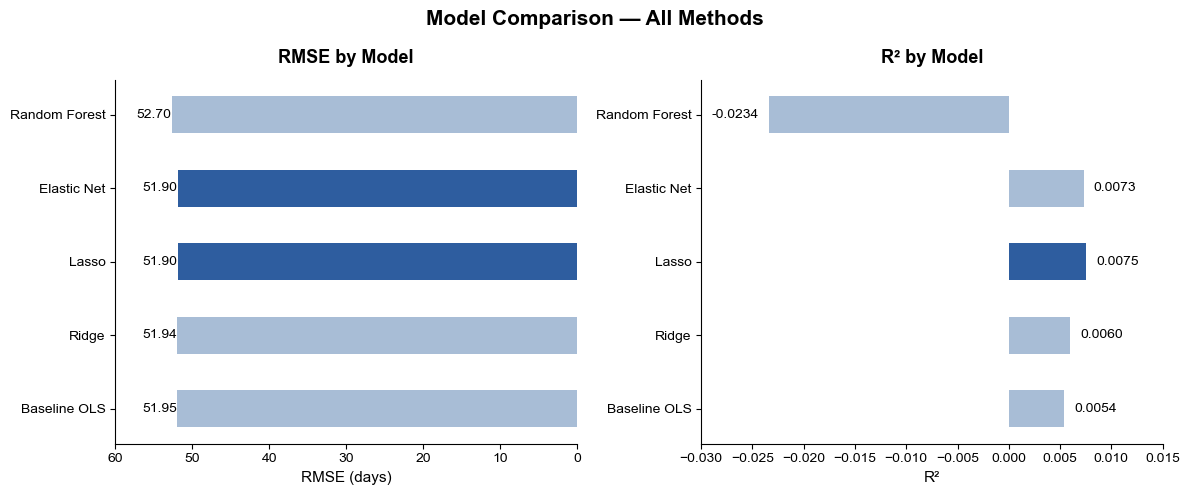

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison — All Methods', fontsize=15, fontweight='bold')

models = results['Model']
rmse_values = results['RMSE']
r2_values = results['R²']

rmse_colors = ['#2E5D9F' if v == min(rmse_values) else '#A8BDD6' for v in rmse_values]
axes[0].barh(models, rmse_values, color=rmse_colors, height=0.5)
axes[0].set_xlabel('RMSE (days)', fontsize=11)
axes[0].set_title('RMSE by Model', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlim(0, 60)
axes[0].invert_xaxis()
for i, v in enumerate(rmse_values):
    axes[0].text(v - 0.000001, i, f'{v:.2f}', va='center', fontsize=10, ha='right')

r2_colors = ['#2E5D9F' if v == max(r2_values) else '#A8BDD6' for v in r2_values]
axes[1].barh(models, r2_values, color=r2_colors, height=0.5)
axes[1].set_xlabel('R²', fontsize=11)
axes[1].set_title('R² by Model', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlim(-0.03, 0.015)
for i, v in enumerate(r2_values):
    if v >= 0:
        axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, ha='left')
    else:
        axes[1].text(v - 0.001, i, f'{v:.4f}', va='center', fontsize=10, ha='right')

plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Key Findings

Across all five models, predictive performance is consistently low, with RMSE 
hovering near 52 days against a mean approval duration of 28 days. No model 
explains more than 0.75% of the variance in approval duration, and the Random 
Forest model fails to generalize despite capturing non-linear relationships.

These results point to a fundamental data limitation: the categorical features 
available in the DOB permit dataset; job type, work type, borough, building 
type, and residential classification; do not contain sufficient signal to 
reliably predict how long a permit will take to be approved. Permit duration 
appears to be driven by factors not captured in this dataset, such as plan 
examiner workload, application completeness, objection history, and applicant 
experience.

Lasso regression is selected as the preferred model on the basis of parsimony;
it achieves the best R² using only 12 of 30 predictors, with work type and 
permit type emerging as the most informative features.

#### Limitations and Future Work

* **Feature availability:** The dataset lacks continuous predictors such as 
construction cost, floor area, and number of objections filed, which are likely 
stronger drivers of approval duration.
* **Sample scope:** Analysis is limited to 100,000 records pulled via API. 
The full dataset contains millions of records and may reveal stronger patterns 
at scale.
* **Temporal features:** Filing year, month, and season were not included as 
predictors. Permit processing times likely vary with DOB staffing and policy 
changes over time.
* **Future work:** Enriching the dataset with job application filing data, 
objection counts, and applicant license type could substantially improve 
predictive performance. A classification framing, predicting whether a permit 
will be delayed beyond a threshold, may also yield more actionable results.

#### Conclusions

This project demonstrates a full regression modeling pipeline applied to a 
real-world AEC dataset; from API data acquisition through feature engineering, 
baseline modeling, regularization, and tree-based methods. While predictive 
performance is limited by available features, the analysis surfaces meaningful 
patterns in NYC construction permitting and illustrates the kind of structured, 
data-driven inquiry that can support project planning in the built environment.